In [3]:
%%capture
!pip install bertopic
!pip install datasets
!pip install optuna
!pip install gensim

In [4]:
from google.colab import userdata
import os

os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

## Load abstract corpus

In [ ]:
import requests
import argparse
import sys
import os
import pandas as pd
from urllib.parse import urlencode

In [ ]:
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
shared_url = 'https://disk.yandex.ru/d/gC2HjizA3KQFIA'

In [ ]:
final_url = base_url + urlencode(dict(public_key = shared_url))
response = requests.get(final_url)
download_url = response.json()['href']
download_response = requests.get(download_url)

In [ ]:
filename = "Data/SIRT6_abstracts_corpus.csv"
os.makedirs(os.path.dirname(filename), exist_ok=True)
with open(filename, 'wb') as f:
    f.write(download_response.content)

In [ ]:
abstract_corpus = pd.read_csv(filename)

In [ ]:
abstract_corpus.head()

,titles,abstracts,year
0,Genomic Instability and Aging-like Phenotype i...,The Sir2 histone deacetylase functions as a ch...,2006-01-01
1,SIRT6 is a histone H3 lysine 9 deacetylase tha...,The Sir2 deacetylase regulates chromatin silen...,2008-01-01
2,SIRT6 Links Histone H3 Lysine 9 Deacetylation ...,Members of the sirtuin (SIRT) family of NAD-de...,2009-01-01
3,The sirtuin SIRT6 regulates lifespan in male mice,The significant increase in human lifespan dur...,2012-01-01
4,The Histone Deacetylase Sirt6 Regulates Glucos...,SIRT6 is a member of a highly conserved family...,2010-01-01


In [ ]:
abstracts = abstract_corpus['abstracts']
titles = abstract_corpus['titles']
years = abstract_corpus['year']

In [ ]:
title_abstracts = (
    abstract_corpus["titles"].fillna("") +
    ". " +
    abstract_corpus["abstracts"].fillna("")
).tolist()

In [ ]:
title_abstracts[0]

'Genomic Instability and Aging-like Phenotype in the Absence of Mammalian SIRT6. The Sir2 histone deacetylase functions as a chromatin silencer to regulate recombination, genomic stability, and aging in budding yeast. Seven mammalian Sir2 homologs have been identified (SIRT1-SIRT7), and it has been speculated that some may have similar functions to Sir2. Here, we demonstrate that SIRT6 is a nuclear, chromatin-associated protein that promotes resistance to DNA damage and suppresses genomic instability in mouse cells, in association with a role in base excision repair (BER). SIRT6-deficient mice are small and at 2-3 weeks of age develop abnormalities that include profound lymphopenia, loss of subcutaneous fat, lordokyphosis, and severe metabolic defects, eventually dying at about 4 weeks. We conclude that one function of SIRT6 is to promote normal DNA repair, and that SIRT6 loss leads to abnormalities in mice that overlap with aging-associated degenerative processes.'

In [ ]:
abstracts[0]

'The Sir2 histone deacetylase functions as a chromatin silencer to regulate recombination, genomic stability, and aging in budding yeast. Seven mammalian Sir2 homologs have been identified (SIRT1-SIRT7), and it has been speculated that some may have similar functions to Sir2. Here, we demonstrate that SIRT6 is a nuclear, chromatin-associated protein that promotes resistance to DNA damage and suppresses genomic instability in mouse cells, in association with a role in base excision repair (BER). SIRT6-deficient mice are small and at 2-3 weeks of age develop abnormalities that include profound lymphopenia, loss of subcutaneous fat, lordokyphosis, and severe metabolic defects, eventually dying at about 4 weeks. We conclude that one function of SIRT6 is to promote normal DNA repair, and that SIRT6 loss leads to abnormalities in mice that overlap with aging-associated degenerative processes.'

## Pre-calculate Embeddings

In [ ]:
model_name = "google/embeddinggemma-300M"

In [ ]:
from sentence_transformers import SentenceTransformer

# Pre-calculate embeddings
embedding_model = SentenceTransformer(model_name)
embeddings = embedding_model.encode(title_abstracts, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/573 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

3_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

Batches:   0%|          | 0/52 [00:00<?, ?it/s]

## Improving representations with removing stop words

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [ ]:
domain_stopwords = {
    "sirt6", "sirtuin", "sirtuins",
    "activity", "activities",
    "level", "levels",
    "expression", "expressed",
    "protein", "proteins", "gene", "genes"
}

In [ ]:
stopwords = set(ENGLISH_STOP_WORDS).union(domain_stopwords)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_model = CountVectorizer(stop_words = list(stopwords), #"english",
                                   min_df=2,
                                   ngram_range=(1, 2))

## Changing default representations

In [ ]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech

# KeyBERT
keybert_model = KeyBERTInspired()

# Part-of-Speech
pos_model = PartOfSpeech("en_core_web_sm",
                         pos_patterns=[
        [{"POS": "ADJ"}, {"POS": "NOUN"}],
        [{"POS": "NOUN"}, {"POS": "NOUN"}]
])

# MMR
mmr_model = MaximalMarginalRelevance(diversity=0.3)

# All representation models
representation_model = {
    "KeyBERT": keybert_model,
    # "OpenAI": openai_model,  # Uncomment if you will use OpenAI
    "MMR": mmr_model,
    "POS": pos_model
}

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## UMAP

In [ ]:
from umap import UMAP

In [ ]:
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

## HDBSCAN + hyperparameter tuning

In [ ]:
from hdbscan import HDBSCAN
import optuna
import numpy as np

In [ ]:
hdbscan_model = HDBSCAN(min_cluster_size = 25,
                        metric = 'euclidean',
                        cluster_selection_method='eom',
                        prediction_data=True)

## Training

In [ ]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

In [ ]:
topic_model = BERTopic(
  ctfidf_model = ClassTfidfTransformer(bm25_weighting=True,
                                       reduce_frequent_words=True),

  # Pipeline models
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  vectorizer_model=vectorizer_model,
  representation_model=representation_model,


  # Hyperparameters
  top_n_words=10,
  min_topic_size = 10, ## can be skipped due to usage of HDBSCAN
  verbose=True
)

topics, probs = topic_model.fit_transform(title_abstracts, embeddings)

2026-03-11 07:57:15,063 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-11 07:57:28,098 - BERTopic - Dimensionality - Completed ✓
2026-03-11 07:57:28,099 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-11 07:57:28,153 - BERTopic - Cluster - Completed ✓
2026-03-11 07:57:28,157 - BERTopic - Representation - Fine-tuning topics using representation models.


In [ ]:
base_topics = topic_model.get_topic_info()
base_topics.to_csv("Data/Base_topic_info.csv")

In [ ]:
topic_model.get_topic_info()

In [ ]:
import json

In [ ]:
number_of_topics = base_topics.Topic.values.max()

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.float32, np.float64, np.int32, np.int64)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

dirname = "Data/Base_topics/"
os.makedirs(os.path.dirname(dirname), exist_ok=True)

for topic_num in range(number_of_topics):
  representation = topic_model.get_topic(topic_num, full=True)
  with open(f"Data/Base_topics/Base_topic_{topic_num}.json", "w") as f:
    json.dump(representation, f, cls=NumpyEncoder, indent=2)
#topic_model.get_topic(0, full=True)

In [ ]:
topic_model.get_topic(8, full=True)

In [ ]:
topic_model.get_topic(4, full=True)

In [ ]:
document_info = topic_model.get_document_info(title_abstracts)
document_info.head()

In [ ]:
document_info.to_csv("Data/Base_document_info.csv")

Cluster analysis (Gini, Shannon entropy, etc)

In [ ]:
from collections import Counter
import numpy as np

In [ ]:
def calculate_topic_metrics(topic_model, docs=None, topics=None):
    """
    Calculate Gini coefficient and effective number of clusters for BERTopic results.

    Parameters:
    -----------
    topic_model : BERTopic model
        Fitted BERTopic model
    docs : list, optional
        List of documents (if topics not provided directly)
    topics : list, optional
        Pre-computed topic assignments (if docs not provided)

    Returns:
    --------
    dict: Dictionary containing all metrics
    """

    # Get topic assignments if not provided
    if topics is None and docs is not None:
        topics, _ = topic_model.transform(docs)
    elif topics is None:
        # If model is already fitted, get the topics from the model
        topics = topic_model.topics_

    # Count documents per topic
    # Exclude -1 (outliers) if desired - adjust based on your needs
    topic_counts = Counter([t for t in topics if t != -1])

    # Convert to array of counts
    counts = np.array(list(topic_counts.values()))

    if len(counts) == 0:
        return {"error": "No non-outlier topics found"}

    # Sort counts for Gini calculation
    counts_sorted = np.sort(counts)
    n = len(counts_sorted)

    # Calculate Gini coefficient
    # Formula: G = (2 * Σ(i * y_i)) / (n * Σy) - (n+1)/n
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * counts_sorted)) / (n * np.sum(counts_sorted)) - (n + 1) / n

    # Calculate proportions
    props = counts / np.sum(counts)

    # Shannon entropy
    shannon_entropy = -np.sum(props * np.log(props + 1e-10))  # Add small epsilon to avoid log(0)
    effective_shannon = np.exp(shannon_entropy)

    # Inverse Simpson
    inv_simpson = 1 / np.sum(props ** 2)

    # Additional metrics
    n_topics = len(counts)
    n_outliers = np.sum([1 for t in topics if t == -1])
    total_docs = len(topics)

    # Calculate Gini for outlier-inclusive distribution if needed
    counts_with_outliers = Counter(topics)
    counts_all = np.array(list(counts_with_outliers.values()))
    counts_all_sorted = np.sort(counts_all)
    n_all = len(counts_all_sorted)
    index_all = np.arange(1, n_all + 1)
    gini_all = (2 * np.sum(index_all * counts_all_sorted)) / (n_all * np.sum(counts_all_sorted)) - (n_all + 1) / n_all

    return {
        "n_topics": n_topics,
        "n_outliers": n_outliers,
        "outlier_percentage": (n_outliers / total_docs) * 100,
        "gini_coefficient": gini,
        "gini_with_outliers": gini_all,
        "shannon_entropy": shannon_entropy,
        "effective_shannon": effective_shannon,
        "inverse_simpson": inv_simpson,
        "min_cluster_size": np.min(counts),
        "max_cluster_size": np.max(counts),
        "mean_cluster_size": np.mean(counts),
        "median_cluster_size": np.median(counts)
    }

def print_topic_metrics(metrics):
    """Pretty print the metrics"""
    print("=" * 50)
    print("TOPIC MODEL METRICS")
    print("=" * 50)
    print(f"Number of non-outlier topics: {metrics['n_topics']}")
    print(f"Number of outliers: {metrics['n_outliers']} ({metrics['outlier_percentage']:.1f}%)")
    print(f"\n--- Cluster Size Distribution ---")
    print(f"Min size: {metrics['min_cluster_size']}")
    print(f"Max size: {metrics['max_cluster_size']}")
    print(f"Mean size: {metrics['mean_cluster_size']:.1f}")
    print(f"Median size: {metrics['median_cluster_size']:.1f}")
    print(f"\n--- Inequality Metrics ---")
    print(f"Gini coefficient: {metrics['gini_coefficient']:.3f}")
    print(f"Gini (with outliers): {metrics['gini_with_outliers']:.3f}")
    print(f"\n--- Effective Number of Clusters ---")
    print(f"Shannon entropy: {metrics['shannon_entropy']:.3f}")
    print(f"Effective clusters (Shannon): {metrics['effective_shannon']:.1f}")
    print(f"Effective clusters (Inverse Simpson): {metrics['inverse_simpson']:.1f}")
    print("=" * 50)


In [ ]:
# Calculate metrics
metrics = calculate_topic_metrics(topic_model, topics=None)

# Print results
print_topic_metrics(metrics)

Coherence score

In [ ]:
def compute_coherence(topics, topic_model, docs, representation_name = "Main", measure = "c_npmi"):

    documents = pd.DataFrame({"Document": docs,
                          "ID": range(len(docs)),
                          "Topic": topics})

    documents_per_topic = documents.groupby(['Topic'], as_index=False).agg({'Document': ' '.join})
    cleaned_docs = topic_model._preprocess_text(documents_per_topic.Document.values)

    vectorizer = topic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()

    words = vectorizer.get_feature_names_out()
    tokens = [analyzer(doc) for doc in cleaned_docs]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]
    topic_words = [[words for words, _ in topic_model.get_topic(topic, full = True).get(representation_name)]
               for topic in range(len(set(topics))-1)]

    coherence_model = CoherenceModel(topics=topic_words,
                                 texts=tokens,
                                 corpus=corpus,
                                 dictionary=dictionary,
                                 coherence=measure)

    return coherence_model.get_coherence()

In [ ]:
topic_model.get_topic(1, full = True).keys()

In [ ]:
coherence_score = compute_coherence(
        topics = topics,
        topic_model = topic_model,
        docs = title_abstracts,
        representation_name = "Main",
        measure = "c_npmi"
)

In [ ]:
coherence_score

## Visualizations

In [ ]:
topic_model.visualize_topics()

In [ ]:
from umap import UMAP

Reduce dimensionality of embeddings, this step is optional but much faster to perform iteratively:

In [ ]:
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

In [ ]:
topic_model.visualize_documents(titles, reduced_embeddings=reduced_embeddings, custom_labels=True, hide_annotations=True)

In [ ]:
plot_df = pd.DataFrame({
    "x": reduced_embeddings[:,0],
    "y": reduced_embeddings[:,1],
    "topic": topics,
})

topic_labels = topic_model.get_topic_info().set_index("Topic")["Name"].to_dict()

plot_df["topic_label"] = plot_df["topic"].map(topic_labels)

outliers = plot_df[plot_df["topic"] == -1]
main_topics = plot_df[plot_df["topic"] != -1]

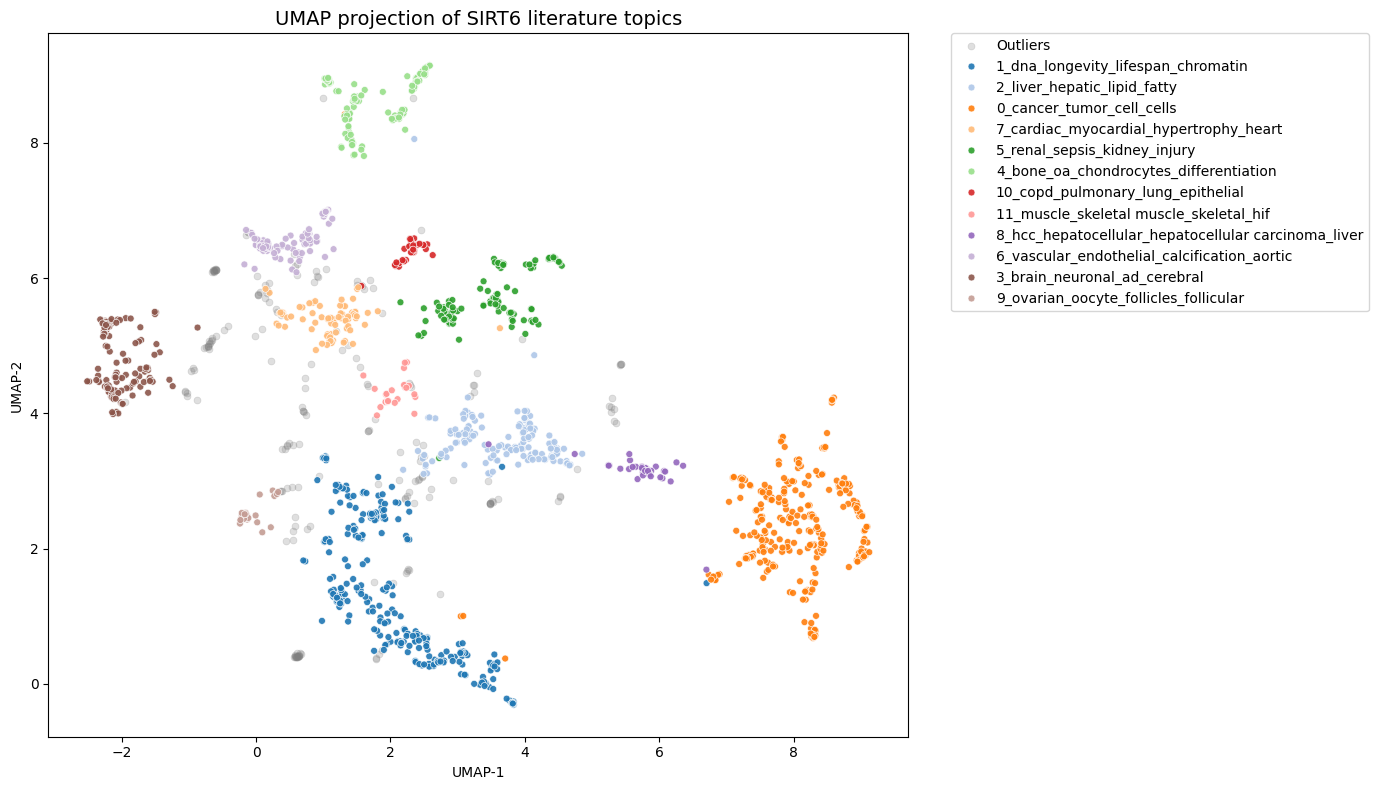

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

plt.scatter(
    outliers["x"],
    outliers["y"],
    color="grey",
    alpha=0.25,
    s=25,
    label="Outliers",
    linewidth=0.5
)

sns.scatterplot(
    data=main_topics,
    x="x",
    y="y",
    hue="topic_label",
    palette="tab20",
    s=25,
    alpha=0.9,
    linewidth=0.5
)

plt.title("UMAP projection of SIRT6 literature topics", fontsize=14)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()

plt.savefig(
    "sirt6_topics_umap.png",
    dpi=300,
    bbox_inches="tight"
)

In [ ]:
import numpy as np

np.save("topics_embeddings.npy", reduced_embeddings)

In [ ]:
plot_df.to_csv("bertopic_umap_embeddings.csv", index=False)

## Save model

In [ ]:
embedding_model = "google/embeddinggemma-300M"

folder_name = "Output_data"

topic_model.save(folder_name,
                 serialization="safetensors",
                 save_ctfidf=True,
                 save_embedding_model=embedding_model)

 # Zero-shot modeling

In [ ]:
aging_hallmarks = [
    "Genome instability",
    "Telomere attrition",
    "Epigenetic alterations",
    "Loss of proteostasis",
    "Disabled macroautophagy",
    "Deregulated nutrient sensing",
    "Mitochondrial dysfunction",
    "Cellular senescence",
    "Stem cell exhaustion",
    "Intercellular communication",
    "Chronic inflammation",
    "Dysbiosis",
    "Extracellular matrix changes",
    "Psychosocial isolation"
]


In [ ]:
hallmark_descriptions_v2 = {

    "Genome instability":
        "DNA damage response, genomic instability, DNA repair mechanisms, double strand breaks, chromosomal instability, replication stress, genome maintenance",

    "Telomere attrition":
        "telomere shortening, telomere dysfunction, telomerase activity, chromosome end protection, replicative aging, telomere maintenance",

    "Epigenetic alterations":
        "epigenetic regulation, chromatin remodeling, histone modification, histone acetylation and deacetylation, DNA methylation, chromatin state regulation, transcriptional regulation",

    "Loss of proteostasis":
        "protein homeostasis, misfolded proteins, protein aggregation, chaperone systems, unfolded protein response, proteasome dysfunction, protein quality control",

    "Disabled macroautophagy":
        "macroautophagy impairment, autophagy regulation, lysosomal degradation, autophagosome formation, autophagic flux, cellular recycling mechanisms",

    "Deregulated nutrient sensing":
        "nutrient sensing pathways, insulin signaling, IGF signaling, mTOR pathway, AMPK signaling, NAD metabolism, metabolic regulation, caloric restriction pathways",

    "Mitochondrial dysfunction":
        "mitochondrial metabolism, oxidative phosphorylation, mitochondrial biogenesis, mitochondrial stress response, reactive oxygen species production, mitochondrial DNA damage",

    "Cellular senescence":
        "cellular senescence, senescence associated secretory phenotype, cell cycle arrest, p16INK4a pathway, p21 signaling, senescence biomarkers",

    "Stem cell exhaustion":
        "stem cell aging, stem cell depletion, impaired stem cell renewal, progenitor cell dysfunction, tissue regeneration decline",

    "Intercellular communication":
        "cell cell signaling, cytokine signaling, extracellular vesicles, endocrine signaling, paracrine communication, immune signaling pathways",

    "Chronic inflammation":
        "chronic inflammation, inflammatory signaling pathways, NF kappa B activation, inflammaging, cytokine production, immune activation",

    "Dysbiosis":
        "gut microbiome imbalance, microbiota composition changes, microbial metabolites, host microbiome interaction, intestinal microbiota dysregulation",

    "Extracellular matrix changes":
        "extracellular matrix remodeling, ECM stiffness, collagen remodeling, matrix metalloproteinases, tissue fibrosis, extracellular matrix degradation, cell matrix interaction",

    "Psychosocial isolation":
        "social isolation, psychosocial stress, loneliness, social environment effects on health, neuroendocrine stress response, behavioral and psychological stress factors"
}

In [ ]:
hdbscan_model = HDBSCAN(min_cluster_size = 10,
                        metric = 'euclidean',
                        cluster_selection_method='eom',
                        prediction_data=True)

In [ ]:
from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    zeroshot_topic_list=list(hallmark_descriptions_v2.values()),
    zeroshot_min_similarity=0.3,
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(abstracts, embeddings)

2026-03-06 11:58:00,293 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-06 11:58:09,655 - BERTopic - Dimensionality - Completed ✓
2026-03-06 11:58:09,656 - BERTopic - Zeroshot Step 1 - Finding documents that could be assigned to either one of the zero-shot topics
2026-03-06 11:58:09,766 - BERTopic - Zeroshot Step 1 - Completed ✓
2026-03-06 11:58:17,836 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-06 11:58:17,915 - BERTopic - Cluster - Completed ✓
2026-03-06 11:58:17,920 - BERTopic - Zeroshot Step 2 - Combining topics from zero-shot topic modeling with topics from clustering...
2026-03-06 11:58:17,955 - BERTopic - Zeroshot Step 2 - Completed ✓
2026-03-06 11:58:17,958 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-06 11:58:19,414 - BERTopic - Representation - Completed ✓


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,30,-1_cad_mg_patients_imu 856,"[cad, mg, patients, imu 856, imu, 856, study, ...","[and Objective: SGLT2 inhibitors, primarily us..."
1,0,45,"DNA damage response, genomic instability, DNA ...","[dna, repair, dna damage, damage, dna repair, ...",[Deregulation of the DNA damage response (DDR)...
2,1,234,"telomere shortening, telomere dysfunction, tel...","[aging, dna, age, longevity, telomere, lifespa...",[Studies reveal that caloric restriction (CR) ...
3,2,66,"epigenetic regulation, chromatin remodeling, h...","[histone, gene, genes, acetylation, pax3, chro...",[The Sir2 histone deacetylase gene family cons...
4,3,18,"protein homeostasis, misfolded proteins, prote...","[allosteric, sites, yap, usp10, cardiac, lysin...",[Acylation of lysine is an important protein m...
5,4,25,"macroautophagy impairment, autophagy regulatio...","[autophagy, cells, nasal, group, warburg effec...",[Our previous study has demonstrated SIRT6 pro...
6,5,157,"nutrient sensing pathways, insulin signaling, ...","[mice, glucose, metabolic, liver, metabolism, ...",[Adipose tissue inflammation is a reproducible...
7,6,224,"mitochondrial metabolism, oxidative phosphoryl...","[mitochondrial, oxidative, stress, induced, ox...",[The sirtuin 6 (SIRT6) participates in regulat...
8,7,230,"cellular senescence, senescence associated sec...","[cells, cancer, cell, senescence, tumor, induc...","[Fibroblast growth factor receptor 4 (FGFR4), ..."
9,8,139,"stem cell aging, stem cell depletion, impaired...","[cells, cell, aging, senescence, mice, differe...",[Autologous bone marrow mesenchymal stem cell ...


In [ ]:
zeroshot_topics = topic_model.get_topic_info()
zeroshot_topics.to_csv("Data/Zeroshot_topic_info.csv")

In [ ]:
number_of_topics = zeroshot_topics.Topic.values.max()

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.float32, np.float64, np.int32, np.int64)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

dirname = "Data/Zeroshot_topics/"
os.makedirs(os.path.dirname(dirname), exist_ok=True)

for topic_num in range(number_of_topics):
  representation = topic_model.get_topic(topic_num, full=True)
  with open(f"Data/Zeroshot_topics/Zeroshot_topic_{topic_num}.json", "w") as f:
    json.dump(representation, f, cls=NumpyEncoder, indent=2)
#topic_model.get_topic(0, full=True)

In [ ]:
topic_model.get_topic_info().iloc[1:12].Count.sum()

np.int64(1333)

In [ ]:
document_info = topic_model.get_document_info(abstracts)
document_info.head()

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,The Sir2 histone deacetylase functions as a ch...,1,"telomere shortening, telomere dysfunction, tel...","[aging, dna, age, longevity, telomere, lifespa...",[Studies reveal that caloric restriction (CR) ...,aging - dna - age - longevity - telomere - lif...,0.865740,False
1,The Sir2 deacetylase regulates chromatin silen...,1,"telomere shortening, telomere dysfunction, tel...","[aging, dna, age, longevity, telomere, lifespa...",[Studies reveal that caloric restriction (CR) ...,aging - dna - age - longevity - telomere - lif...,0.832472,False
2,Members of the sirtuin (SIRT) family of NAD-de...,1,"telomere shortening, telomere dysfunction, tel...","[aging, dna, age, longevity, telomere, lifespa...",[Studies reveal that caloric restriction (CR) ...,aging - dna - age - longevity - telomere - lif...,0.824527,False
3,The significant increase in human lifespan dur...,1,"telomere shortening, telomere dysfunction, tel...","[aging, dna, age, longevity, telomere, lifespa...",[Studies reveal that caloric restriction (CR) ...,aging - dna - age - longevity - telomere - lif...,0.806956,False
4,SIRT6 is a member of a highly conserved family...,5,"nutrient sensing pathways, insulin signaling, ...","[mice, glucose, metabolic, liver, metabolism, ...",[Adipose tissue inflammation is a reproducible...,mice - glucose - metabolic - liver - metabolis...,0.798112,False


In [ ]:
document_info.to_csv("Data/Zeroshot_document_info.csv")

In [ ]:
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

In [ ]:
topic_model.visualize_documents(titles, reduced_embeddings=reduced_embeddings, custom_labels=True, hide_annotations=True)

In [ ]:
topic_model.visualize_hierarchy(custom_labels=True)

In [ ]:
topics_over_time = topic_model.topics_over_time(abstracts, years)

28it [00:02,  9.40it/s]


In [ ]:
topics_over_time.to_csv("Data/Zeroshot_topics_over_time.csv")

In [ ]:
topic_model.visualize_topics_over_time(topics_over_time)

In [ ]:
topics_over_time

,Topic,Words,Frequency,Timestamp,Name
0,1,"oe, lifespan, ribosome biogenesis, ribosome, l...",1,1986-01-01,"telomere shortening, telomere dysfunctio..."
1,6,"copd, sirt1, effects, fibrosis, limitation",2,1996-01-01,"mitochondrial metabolism, oxidative phos..."
2,5,"fasting, t2dm, insulin, insulin resistance, co...",1,1999-01-01,"nutrient sensing pathways, insulin signa..."
3,16,"classes, class, iv, bacteria, ii",1,2000-01-01,16_selection_evolutionary_genes_gene
4,2,"sir2, histone, gene, acetylation, histone acet...",2,2003-01-01,"epigenetic regulation, chromatin remodel..."
...,...,...,...,...,...
266,7,"line1, cgas sting, cgas, sting, senescence",1,2026-01-01,"cellular senescence, senescence associat..."
267,10,"tbk1, ifn, ubcs039, lactylation, mice",3,2026-01-01,"chronic inflammation, inflammatory signa..."
268,12,"calcification, vascular calcification, vascula...",1,2026-01-01,"extracellular matrix remodeling, ECM sti..."
269,13,"sleep, day, sd, recovery, 14",1,2026-01-01,"social isolation, psychosocial stress, l..."


## Hallmark similarity fingerprint

In [ ]:
hallmark_descriptions_v2 = {

    "Genome instability":
        "DNA damage response, genomic instability, DNA repair mechanisms, double strand breaks, chromosomal instability, replication stress, genome maintenance",

    "Telomere attrition":
        "telomere shortening, telomere dysfunction, telomerase activity, chromosome end protection, replicative aging, telomere maintenance",

    "Epigenetic alterations":
        "epigenetic regulation, chromatin remodeling, histone modification, histone acetylation and deacetylation, DNA methylation, chromatin state regulation, transcriptional regulation",

    "Loss of proteostasis":
        "protein homeostasis, misfolded proteins, protein aggregation, chaperone systems, unfolded protein response, proteasome dysfunction, protein quality control",

    "Disabled macroautophagy":
        "macroautophagy impairment, autophagy regulation, lysosomal degradation, autophagosome formation, autophagic flux, cellular recycling mechanisms",

    "Deregulated nutrient sensing":
        "nutrient sensing pathways, insulin signaling, IGF signaling, mTOR pathway, AMPK signaling, NAD metabolism, metabolic regulation, caloric restriction pathways",

    "Mitochondrial dysfunction":
        "mitochondrial metabolism, oxidative phosphorylation, mitochondrial biogenesis, mitochondrial stress response, reactive oxygen species production, mitochondrial DNA damage",

    "Cellular senescence":
        "cellular senescence, senescence associated secretory phenotype, cell cycle arrest, p16INK4a pathway, p21 signaling, senescence biomarkers",

    "Stem cell exhaustion":
        "stem cell aging, stem cell depletion, impaired stem cell renewal, progenitor cell dysfunction, tissue regeneration decline",

    "Intercellular communication":
        "cell cell signaling, cytokine signaling, extracellular vesicles, endocrine signaling, paracrine communication, immune signaling pathways",

    "Chronic inflammation":
        "chronic inflammation, inflammatory signaling pathways, NF kappa B activation, inflammaging, cytokine production, immune activation",

    "Dysbiosis":
        "gut microbiome imbalance, microbiota composition changes, microbial metabolites, host microbiome interaction, intestinal microbiota dysregulation",

    "Extracellular matrix changes":
        "extracellular matrix remodeling, ECM stiffness, collagen remodeling, matrix metalloproteinases, tissue fibrosis, extracellular matrix degradation, cell matrix interaction",

    "Psychosocial isolation":
        "social isolation, psychosocial stress, loneliness, social environment effects on health, neuroendocrine stress response, behavioral and psychological stress factors"
}

In [ ]:
embeddings = embedding_model.encode(abstracts, normalize_embeddings=True, show_progress_bar=True)

Batches:   0%|          | 0/52 [00:00<?, ?it/s]

In [ ]:
hallmark_texts = list(hallmark_descriptions_v2.values())

hallmark_embeddings = embedding_model.encode(
    hallmark_texts,
    normalize_embeddings=True
)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

hallmark_projection = cosine_similarity(
    embeddings,
    hallmark_embeddings
)

In [ ]:
hallmark_projection

array([[0.4703802 , 0.502234  , 0.3973898 , ..., 0.19009282, 0.3122655 ,
        0.18503171],
       [0.35471657, 0.5228335 , 0.31963813, ..., 0.10779949, 0.28859255,
        0.18274955],
       [0.3283394 , 0.4698367 , 0.3946952 , ..., 0.16383116, 0.32885668,
        0.23233554],
       ...,
       [0.26638353, 0.26168102, 0.3824237 , ..., 0.26365376, 0.26572853,
        0.14227167],
       [0.1907232 , 0.1923742 , 0.11883181, ..., 0.1694524 , 0.2817225 ,
        0.19810595],
       [0.14924584, 0.24508923, 0.19955914, ..., 0.1865064 , 0.30094588,
        0.17994788]], dtype=float32)

In [ ]:
import pandas as pd

hallmark_df = pd.DataFrame(
    hallmark_projection,
    columns=list(hallmark_prompts.keys())
)

Text(0.5, 1.0, 'Correlation between Aging Hallmarks')

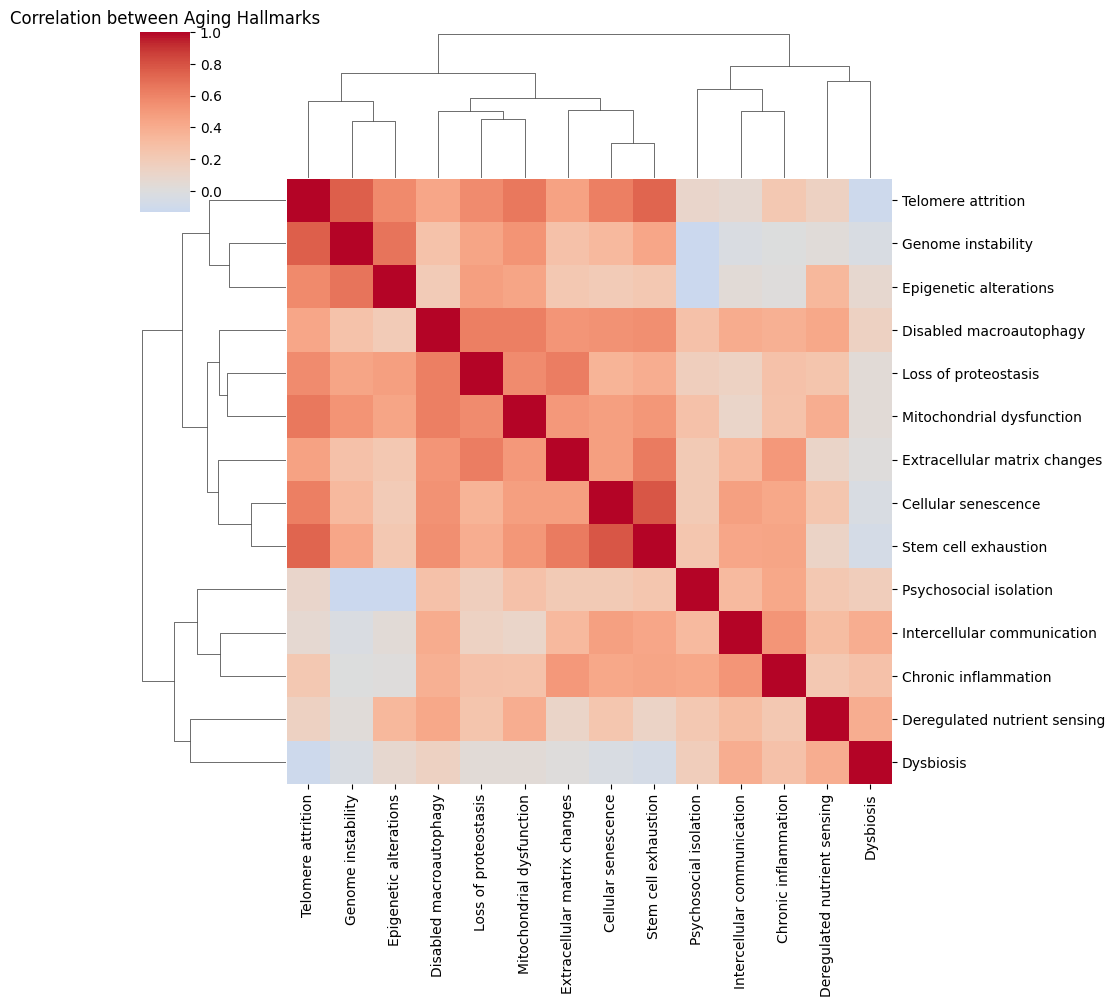

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    hallmark_df.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation between Aging Hallmarks")

In [ ]:
hallmark_df

,Genome instability,Telomere attrition,Epigenetic alterations,Loss of proteostasis,Disabled macroautophagy,Deregulated nutrient sensing,Mitochondrial dysfunction,Cellular senescence,Stem cell exhaustion,Intercellular communication,Chronic inflammation,Dysbiosis,Extracellular matrix changes,Psychosocial isolation
0,0.470380,0.502234,0.397390,0.331236,0.307537,0.304365,0.394480,0.392470,0.426628,0.250589,0.305259,0.190093,0.312265,0.185032
1,0.354717,0.522834,0.319638,0.307410,0.278943,0.259644,0.364999,0.396185,0.379945,0.175491,0.281621,0.107799,0.288593,0.182750
2,0.328339,0.469837,0.394695,0.325915,0.291051,0.357643,0.351088,0.403407,0.368859,0.256952,0.462248,0.163831,0.328857,0.232336
3,0.244661,0.434230,0.281292,0.231010,0.175413,0.318941,0.307218,0.362985,0.333671,0.209639,0.287491,0.177981,0.219913,0.215351
4,0.256633,0.293308,0.354011,0.225651,0.245866,0.392864,0.354960,0.308068,0.278711,0.169723,0.262771,0.185973,0.221245,0.188366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1643,0.242057,0.254546,0.237252,0.179703,0.223831,0.280557,0.215349,0.278928,0.249511,0.211999,0.302013,0.190486,0.183257,0.347475
1644,0.195250,0.212945,0.258768,0.216120,0.216359,0.266385,0.205961,0.267893,0.184077,0.255226,0.304767,0.226812,0.201776,0.137763
1645,0.266384,0.261681,0.382424,0.308220,0.260933,0.361474,0.312200,0.232938,0.257894,0.253805,0.299729,0.263654,0.265729,0.142272
1646,0.190723,0.192374,0.118832,0.206796,0.172597,0.139017,0.287953,0.203348,0.231359,0.158543,0.252768,0.169452,0.281722,0.198106


In [ ]:
import networkx as nx

In [ ]:
X = hallmark_df.values.astype(float)

In [ ]:
row_sums = X.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
X = X / row_sums

In [ ]:
A = X.T @ X

In [ ]:
adj_df = pd.DataFrame(A, index = aging_hallmarks, columns = aging_hallmarks)

In [ ]:
np.fill_diagonal(adj_df.values, 0.0)

In [ ]:
def build_hallmark_graph(adj_df, min_edge_weight=0.01):
    G = nx.Graph()

    for h in adj_df.index:
        G.add_node(h)

    for i, h1 in enumerate(adj_df.index):
        for j, h2 in enumerate(adj_df.columns):
            if j <= i:
                continue
            w = adj_df.iloc[i, j]
            if w >= min_edge_weight:
                G.add_edge(h1, h2, weight=w)

    return G

In [ ]:
G = build_hallmark_graph(adj_df, min_edge_weight=0.02)

In [ ]:
pos = nx.spring_layout(G, weight="weight", seed=42)
edge_weights = [G[u][v]["weight"] for u, v in G.edges]

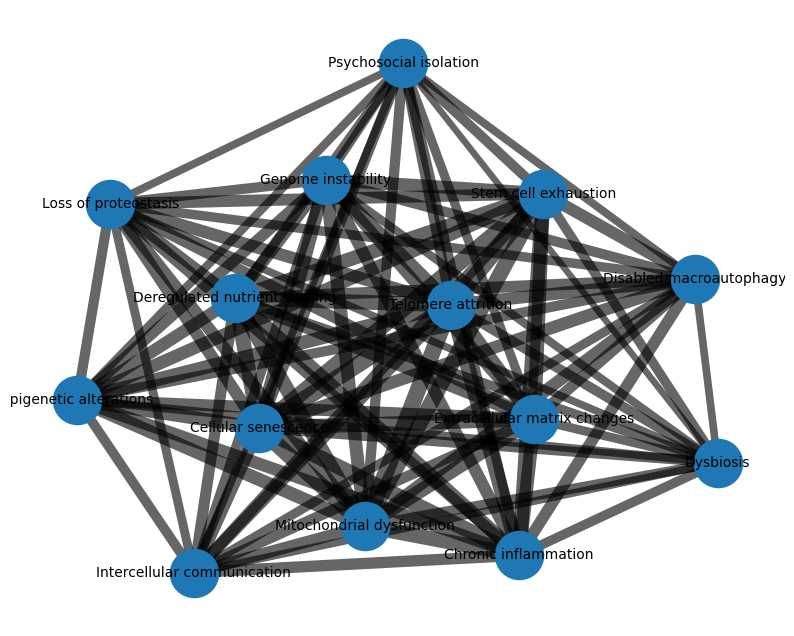

In [ ]:
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_size=1200)
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.axis("off")
plt.show()

## Save data

In [ ]:
!zip -r Data_to_load.zip Data

  adding: Data/ (stored 0%)
  adding: Data/Base_topic_info.csv (deflated 68%)
  adding: Data/Base_document_info.csv (deflated 76%)
  adding: Data/Zeroshot_topics/ (stored 0%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_2.json (deflated 61%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_6.json (deflated 60%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_1.json (deflated 60%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_9.json (deflated 61%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_17.json (deflated 64%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_3.json (deflated 60%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_4.json (deflated 61%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_10.json (deflated 60%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_11.json (deflated 65%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_14.json (deflated 61%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_0.json (deflated 61%)
  adding: Data/Zeroshot_topics/Zeroshot_topic_13.json (deflated 61%)
  ad